# Project Tittle: Climate Change Modeling

**Objective:-** Analyze and model climate change patterns using historical data!

**Approach:-** Data analysis + predictive modelling

**DataSet Source:-** Kaggle

**Author:- Mohammad Iqbal Hurrah**

#  Initial data Exploration and importing ncessary liberaries 
In this phase, we initialize our environment and perform a technical audit of the raw dataset to understand its structure and health.

In [1]:
# Import necesary liberaries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset containing NASA's climate change social media posts
df = pd.read_csv("climate_nasa.csv")

# Display data summary and first few rows
df.info()
print(df.describe())
df.head()

# Initial missing value check
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    object 
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    object 
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.5+ KB
       likesCount  commentsCount
count  522.000000     244.000000
mean     4.720307       8.696721
std     12.053556      12.266176
min      0.000000       1.000000
25%      0.000000       2.000000
50%      1.000000       5.000000
75%      4.000000      10.000000
max    126.000000      93.000000


date               0
likesCount         0
profileName        0
commentsCount    278
text              18
dtype: int64

# Data  Cleaning & Basic Formatting
Data quality is crucial. We handle missing values for comments and text to ensure our calculations don't break and standardize the date formats.

In [2]:
# Statistical summary of text columns
df.describe(include = 'object')

# Filling missing values in critical columns
df['commentsCount'] = df['commentsCount'].fillna(0)
df['text'] = df['text'].fillna(0)

# Convert 'date' to standard datetime format and remove timezone info
df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)

# just for  check
print("Likes Sum: ", df['likesCount'].sum())
print("Comments Sum: ", df['commentsCount'].sum())
df.isnull().sum()

Likes Sum:  2464
Comments Sum:  2122.0


date             0
likesCount       0
profileName      0
commentsCount    0
text             0
dtype: int64

# Chronological Feature Engineering
We extract time-based features like Year and Month. This allows us to track NASA's engagement trends across different time periods.

In [3]:
# Extracting Year and Month
df['Year'] = df['date'].dt.year #Get the year from date column 
df['Month'] = df['date'].dt.month #Get the month column 

# Creating a Year-Month string for chronological sorting
df['Year_Month'] = df['date'].dt.strftime('%Y-%m')

# Aggregate engagement by month
monthly_engagement = df.groupby('Year_Month', as_index=False)[['likesCount','commentsCount']].sum()

# sort from oldest to newest month
monthly_engagement = monthly_engagement.sort_index()

# Ensure numeric types for plotting
monthly_engagement['likesCount'] = pd.to_numeric(monthly_engagement['likesCount'], errors='coerce')
monthly_engagement['commentsCount'] = pd.to_numeric(monthly_engagement['commentsCount'], errors='coerce')

monthly_engagement.head()

,Year_Month,likesCount,commentsCount
0,2020-09,405,597.0
1,2021-09,526,330.0
2,2021-10,196,153.0
3,2021-11,167,93.0
4,2022-09,129,98.0


# Time-Series Visualization (EDA)
Visualizing trends helps identify peaks in public interest. These spikes often correlate with major climate events or viral news.

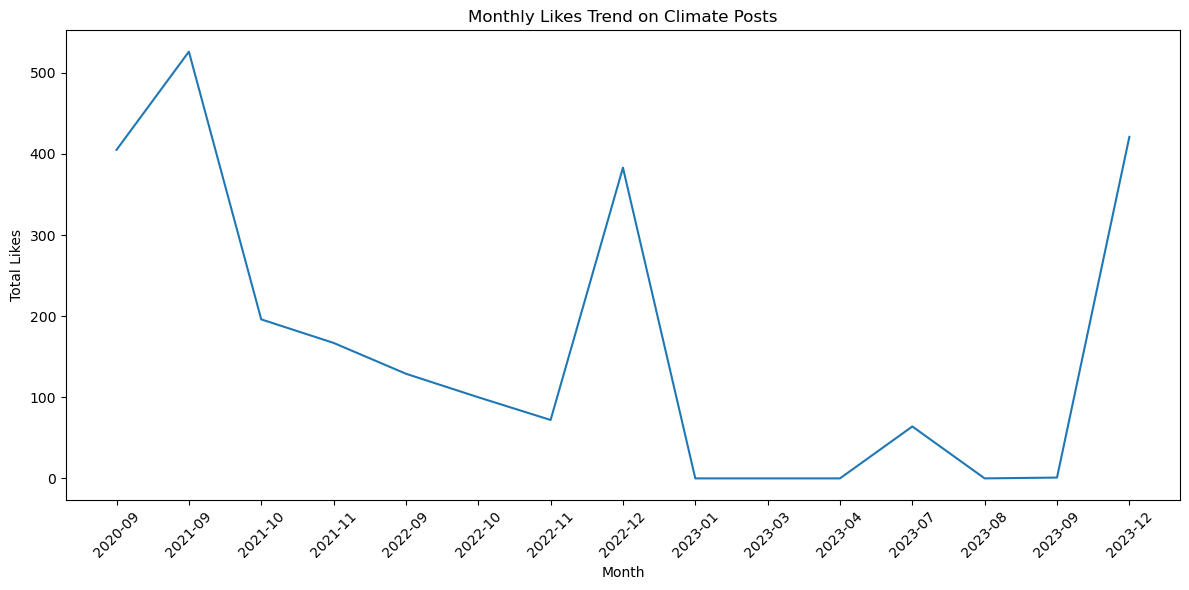

INSIGHTS: 
Engagement through likes shows a sharp spike during September 2021, followed by a decline, indicating temporary audience surges.


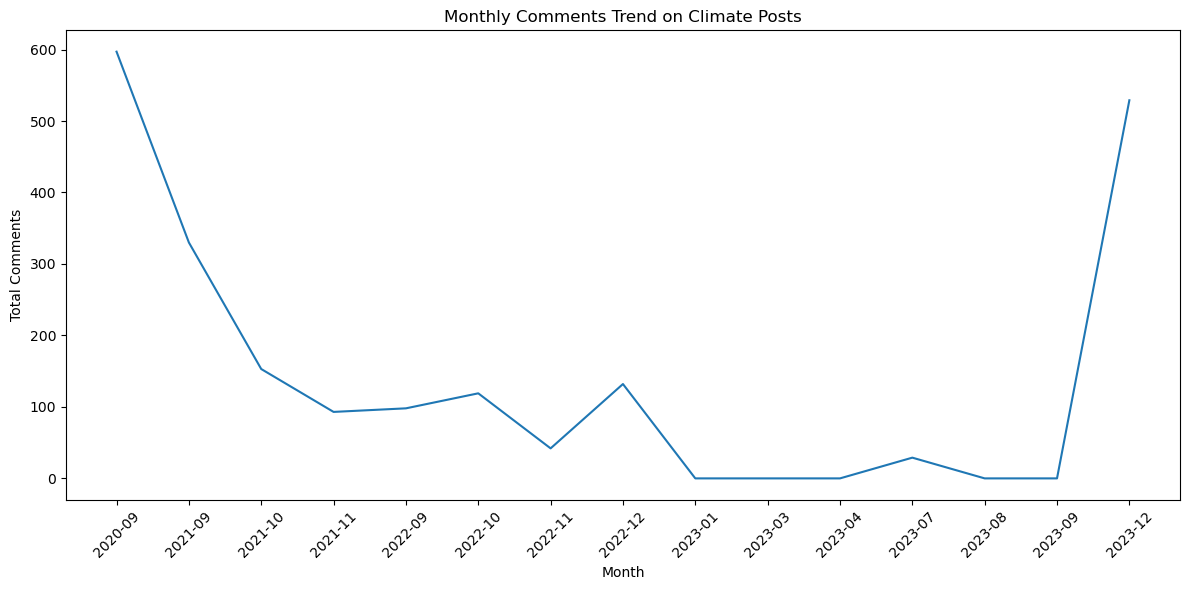

INSIGHTS: 
Comment activity follows a similar pattern to likes, with peaks in Sept 2020 and 2021 triggering more public discussion.


In [4]:
# Plot Monthly Likes Trend
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_engagement, x='Year_Month', y='likesCount')
plt.title("Monthly Likes Trend on Climate Posts")
plt.xlabel("Month")
plt.ylabel("Total Likes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""INSIGHTS: 
Engagement through likes shows a sharp spike during September 2021, followed by a decline, indicating temporary audience surges.""")

# Plot Monthly Comments Trend
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_engagement, x='Year_Month', y='commentsCount')
plt.title("Monthly Comments Trend on Climate Posts")
plt.xlabel("Month")
plt.ylabel("Total Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""INSIGHTS: 
Comment activity follows a similar pattern to likes, with peaks in Sept 2020 and 2021 triggering more public discussion.""")

# Keyword Tagging & Topic Analysis
By classifying posts into topics like 'Ice' , 'Space' , Climate etc, we can determine which content themes are most effective at driving engagement.

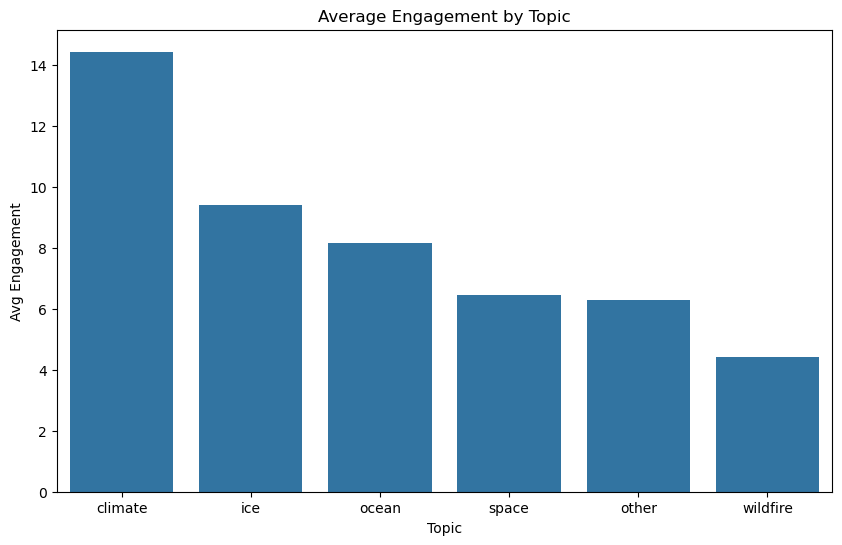

INSIGHTS: 
Topics like 'Climate' and 'Ice' receive higher average engagement compared to general space posts.


In [5]:
# Simple keyword tagging dictionary
topics = {
    'climate': ['climate','warming','temperature'],
    'space': ['space','mars','planet','galaxy'],
    'ocean': ['ocean','sea','water'],
    'ice': ['ice','glacier','arctic','antarctic'],
    'wildfire': ['fire','wildfire','burn'],
}

def get_topic(text):
    text = str(text).lower()
    for topic, words in topics.items():
        for w in words:
            if w in text: return topic
    return 'other'

# Apply topic tagging
df['topic'] = df['text'].apply(get_topic)
df['engagement'] = df['likesCount'] + df['commentsCount']

# Average Engagement by Topic
topic_eng = df.groupby('topic')['engagement'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=topic_eng.index, y=topic_eng.values)
plt.title("Average Engagement by Topic")
plt.xlabel("Topic")
plt.ylabel("Avg Engagement")
plt.show()

print("""INSIGHTS: 
Topics like 'Climate' and 'Ice' receive higher average engagement compared to general space posts.""")

# Behavioral Analysis (Post Length & Timing)
Does a long caption help... 

Does the time of day matter,... 

Here we analyze the correlation between post characteristics and popularity.

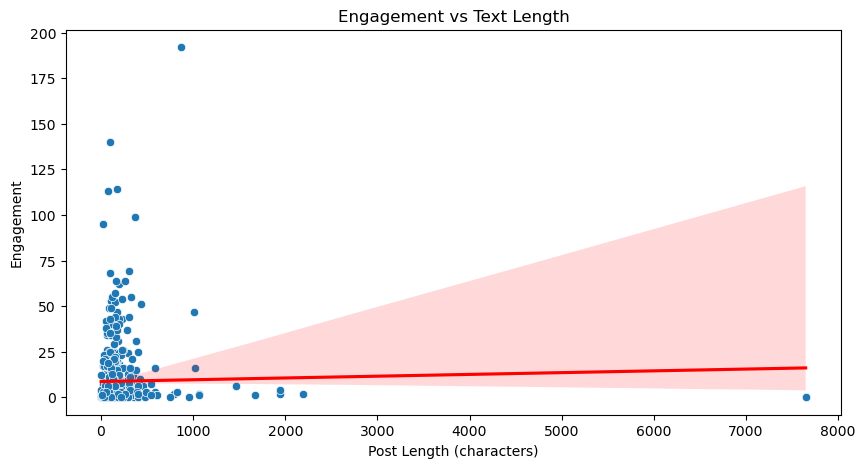

INSIGHTS:
1. Correlation Analysis: The scatter plot and the red regression line indicate the 
   relationship between caption length and engagement. A flat line suggests that 
   audience interaction is independent of post length.
2. Optimal Content Length: If the data points are clustered towards the left, it 
   suggests that shorter, concise posts perform better. 
3. Takeaway: NASA should focus more on the 'Quality' and 'Visual Impact' 
   of the content rather than simply increasing the word count, as character 
   count does not guarantee higher engagement.


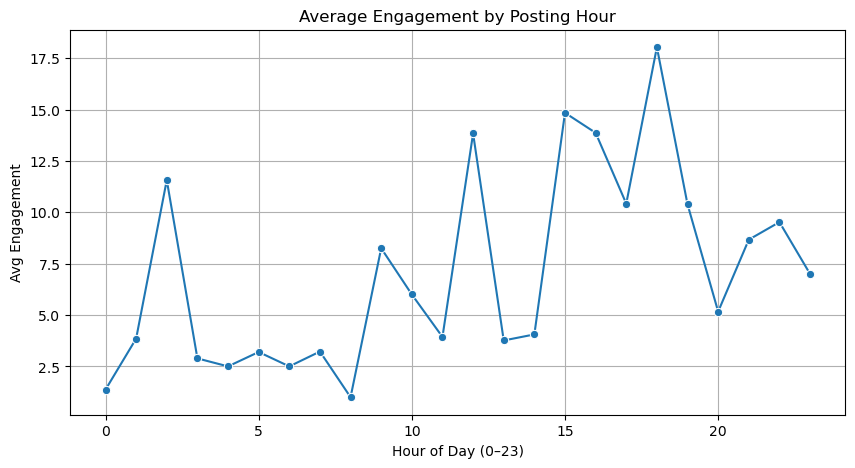

INSIGHTS: 
1. Peak Performance Windows: The line plot identifies specific 'High-Traffic' hours 
   where engagement is at its maximum. These peaks represent the times when the 
   global audience is most active and responsive.
2. Low-Activity Zones: Troughs (low points) in the graph highlight hours where 
   posts are likely to be missed by the majority of the followers.
3. Scheduling Recommendation: To maximize reach and impact, NASA’s high-priority 
   climate updates should be scheduled during the identified peak hours to ensure 
   the content appears at the top of users' feeds.


In [6]:
# Create timing and length columns from date and text columns
df['hour'] = df['date'].dt.hour
df['text_length'] = df['text'].astype(str).apply(len)

# Plot Engagement vs Text Length
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='text_length', y='engagement')
sns.regplot(data=df, x='text_length', y='engagement', scatter=False, color='red') # Trend line
plt.title("Engagement vs Text Length")
plt.xlabel("Post Length (characters)")
plt.ylabel("Engagement")
plt.show()

print("""INSIGHTS:
1. Correlation Analysis: The scatter plot and the red regression line indicate the 
   relationship between caption length and engagement. A flat line suggests that 
   audience interaction is independent of post length.
2. Optimal Content Length: If the data points are clustered towards the left, it 
   suggests that shorter, concise posts perform better. 
3. Takeaway: NASA should focus more on the 'Quality' and 'Visual Impact' 
   of the content rather than simply increasing the word count, as character 
   count does not guarantee higher engagement.""")


# Hourly Trend Analysis
hourly_eng = df.groupby('hour')['engagement'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_eng, x='hour', y='engagement', marker='o')
plt.title("Average Engagement by Posting Hour")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Avg Engagement")
plt.grid(True)
plt.show()

print("""INSIGHTS: 
1. Peak Performance Windows: The line plot identifies specific 'High-Traffic' hours 
   where engagement is at its maximum. These peaks represent the times when the 
   global audience is most active and responsive.
2. Low-Activity Zones: Troughs (low points) in the graph highlight hours where 
   posts are likely to be missed by the majority of the followers.
3. Scheduling Recommendation: To maximize reach and impact, NASA’s high-priority 
   climate updates should be scheduled during the identified peak hours to ensure 
   the content appears at the top of users' feeds.""")

# Identifying Viral Content and Outliers
Identifying the top 5% or 10% of posts allows us to study the "Viral Formula" and understand what triggers massive reach.

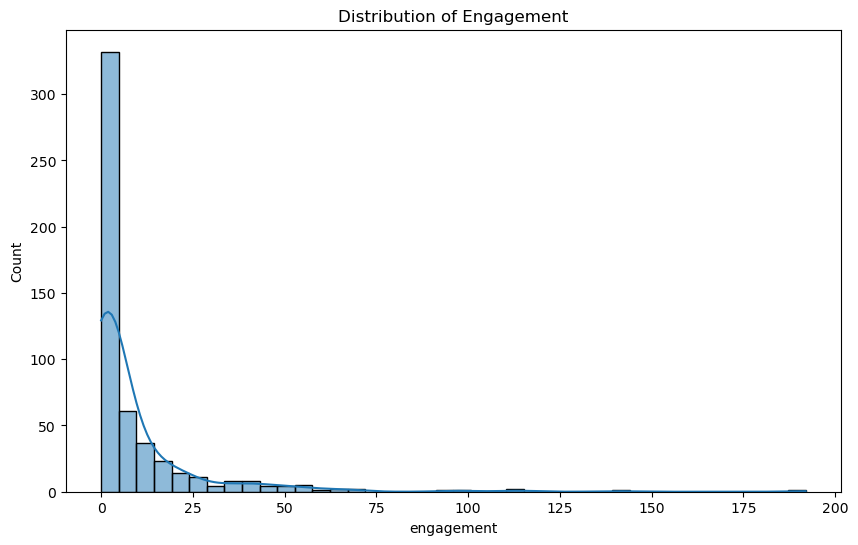

INSIGHTS:
1. The graph shows a 'long tail' to the right, 
   indicating that while the vast majority of posts receive a baseline level 
   of engagement, a small percentage of posts become 'Viral' outliers.
2  Most of the data is concentrated in the lower 
   engagement bins, which represents the consistent, everyday interest of 
   the audience. The rare peaks on the far right represent high-impact 
   content that resonates deeply with the global community.
3. The high-frequency bars on the left define the 
   'Average' performance. NASA can use the engagement scores of the 
   'Viral' outliers to identify the specific type of content (e.g., major 
   discoveries or crisis alerts) that breaks the normal pattern.
                   date                                               text  \
16  2022-09-07 17:29:49  I find it interesting when people claim that C...   
82  2021-09-23 12:55:54  I’m amazed that we’ve been warned since the 70...   
104 2021-09-23 16:28:21  Taking a 140 year

In [7]:
# Statistical Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['engagement'], bins=40, kde=True)
plt.title("Distribution of Engagement")
plt.show()

print("""INSIGHTS:
1. The graph shows a 'long tail' to the right, 
   indicating that while the vast majority of posts receive a baseline level 
   of engagement, a small percentage of posts become 'Viral' outliers.
2  Most of the data is concentrated in the lower 
   engagement bins, which represents the consistent, everyday interest of 
   the audience. The rare peaks on the far right represent high-impact 
   content that resonates deeply with the global community.
3. The high-frequency bars on the left define the 
   'Average' performance. NASA can use the engagement scores of the 
   'Viral' outliers to identify the specific type of content (e.g., major 
   discoveries or crisis alerts) that breaks the normal pattern.""")

# Identifying the top 5% (Viral Posts)
q95 = df['engagement'].quantile(0.95)
viral_posts = df[df['engagement'] >= q95]
print(viral_posts[['date','text','engagement']].head())

# Labeling Top 10% as Viral
cutoff_10 = df['engagement'].quantile(0.90)
df['viral'] = (df['engagement'] >= cutoff_10).astype(int)

# Advanced Patterns Analysis
In this final phase, we analyze weekend versus weekday performance to finalize a data-driven social media strategy for NASA

In [10]:
# 1. Day of week and Weekend flag
df['day'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day'].apply(lambda x: 1 if x>=5 else 0)

df['post_length'] = df['text'].astype(str).apply(len)
# We use the median length to decide if a post is Long (1) or Short (0)
df['is_long'] = (df['post_length'] > df['post_length'].median()).astype(int)

# 4. Grouped Analysis for Strategy
print("--- Strategy Report ---")

# Comparing Weekend vs Weekday
print("\nWeekend vs Weekday Average Engagement:")
print(df.groupby('is_weekend')['engagement'].mean())

# Now 'is_long' will work because we defined it above
print("\nLong vs Short Post Average Engagement:")
print(df.groupby('is_long')['engagement'].mean())

# Checking peak hours
print("\nTop 5 Most Engaging Hours:")
print(df.groupby('hour')['engagement'].mean().sort_values(ascending=False).head(5))

print("""\nFINAL STRATEGY INSIGHTS:
1. Posting on high-traffic hours identified above is recommended.
2. Content strategy should be adjusted based on 'is_long' performance.
3. Weekend patterns help in scheduling future climate updates.""")

--- Strategy Report ---

Weekend vs Weekday Average Engagement:
is_weekend
0    8.697095
1    9.850000
Name: engagement, dtype: float64

Long vs Short Post Average Engagement:
is_long
0     4.352490
1    13.218391
Name: engagement, dtype: float64

Top 5 Most Engaging Hours:
hour
18    18.031250
15    14.840000
16    13.865385
12    13.833333
2     11.565217
Name: engagement, dtype: float64

FINAL STRATEGY INSIGHTS:
1. Posting on high-traffic hours identified above is recommended.
2. Content strategy should be adjusted based on 'is_long' performance.
3. Weekend patterns help in scheduling future climate updates.


# Machine learning model RandomForestRegressor

**(EMISSION PREDICTION)**

In [11]:
# Import necessary liberaries 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Random Forest Model Just Getting Trained")
#  Load DataSets
# 'train' has the answers (emissions), 'test' is what we need to predict
train = pd.read_csv('Model_Data_Sets/train.csv')
test = pd.read_csv('Model_Data_Sets/test.csv')

# Handling Missing Values (Data Cleaning Part)
# Hum missing values ko mean (average) se bhar rahe hain
train.fillna(train.mean(numeric_only=True), inplace=True)
test.fillna(test.mean(numeric_only=True), inplace=True)

# Feature Selection
# 'features' are the inputs (latitude, longitude, etc.)
# 'y' is the target we want to predict (emission)
features = [col for col in train.columns if col not in ['ID_LAT_LON_YEAR_WEEK', 'emission']]
X = train[features]
y = train['emission']

# Data Splitting
# We hide 20% of data (X_val) to test if the model learned correctly
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training (Random Forest)
# n_estimators=50 means 50 different decision trees will work together
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluation (Performance Check)
# MAE Means how much our prediction is off on average
# R2 Score: 1.0 is perfect, shows how well our model fits the data
preds_val = model.predict(X_val)
print(f"Validation MAE: {mean_absolute_error(y_val, preds_val)}")
print(f"R2 Score: {r2_score(y_val, preds_val)}")

# 7. Final Prediction on Test Data
test_preds = model.predict(test[features])  #Predicting emissions for the unknown test set

# 8. Save the result 
submission = pd.read_csv('Model_Data_Sets/sample_submission.csv')
submission['emission'] = test_preds
submission.to_csv('Model_Data_Sets/final_submission.csv', index=False)

print("Work has been done.")

Random Forest Model Just Getting Trained
Validation MAE: 8.415465109691686
R2 Score: 0.9640430511391891
Work has been done.


# Machine learning model HistGradientBoostingRegressor

**(EMISSION PREDICTION)**

In [ ]:
# Import necessary liberaries 
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("HistGradient Boosting Regressor Model Just Getting Trained")
# Load Datasets 
train = pd.read_csv('Model_Data_Sets/train.csv')
test = pd.read_csv('Model_Data_Sets/test.csv')


# Sselect Features
#  HistGradientBoostingRegressor:- this algo. handles missing values by its own
features = [col for col in train.columns if col not in ['ID_LAT_LON_YEAR_WEEK', 'emission']]
X = train[features]
y = train['emission']

# Data Splitting (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fast Model Training (HistGradientBoosting) 
print("Fast Training started...")

# 'max_iter=300' allows the model to learn in 300 sequential steps (boosting rounds)
model = HistGradientBoostingRegressor(random_state=42, max_iter=300)
model.fit(X_train, y_train)

# Check result
preds_val = model.predict(X_val)
print(f"Validation MAE: {mean_absolute_error(y_val, preds_val)}")
print(f"R2 Score: {r2_score(y_val, preds_val)}")

# 5. Final Prediction and Save
test_preds = model.predict(test[features])
submission = pd.read_csv('Model_Data_Sets/sample_submission.csv')
submission['emission'] = test_preds
submission.to_csv('Model_Data_Sets/final_fast_submission.csv', index=False)

print("Job Done, File saved with the name 'final_fast_submission.csv'.")


Random Forest Model Just Getting Trained
Fast Training started...
Validation MAE: 10.712663636662244
R2 Score: 0.9665359733705371
Job Done, File saved with the name 'final_fast_submission.csv'.


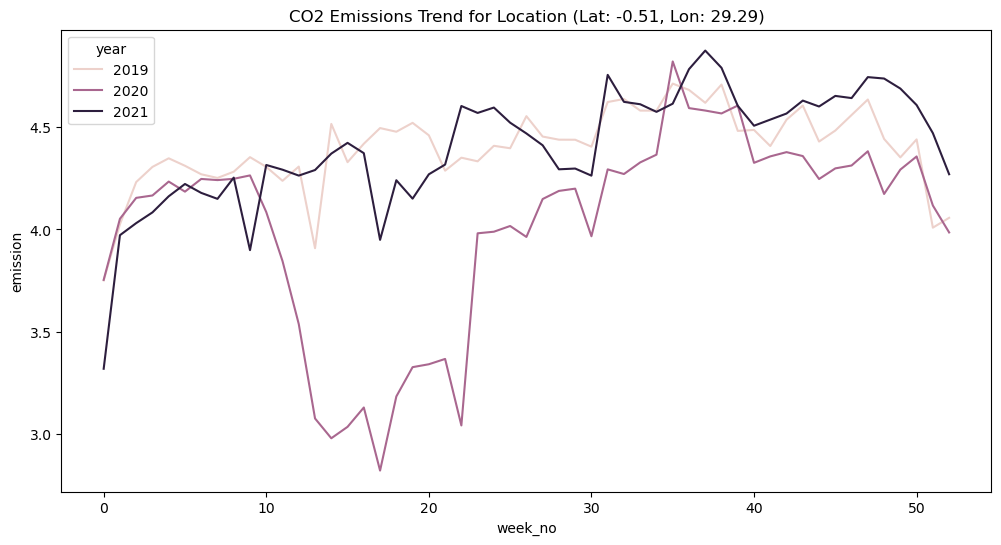

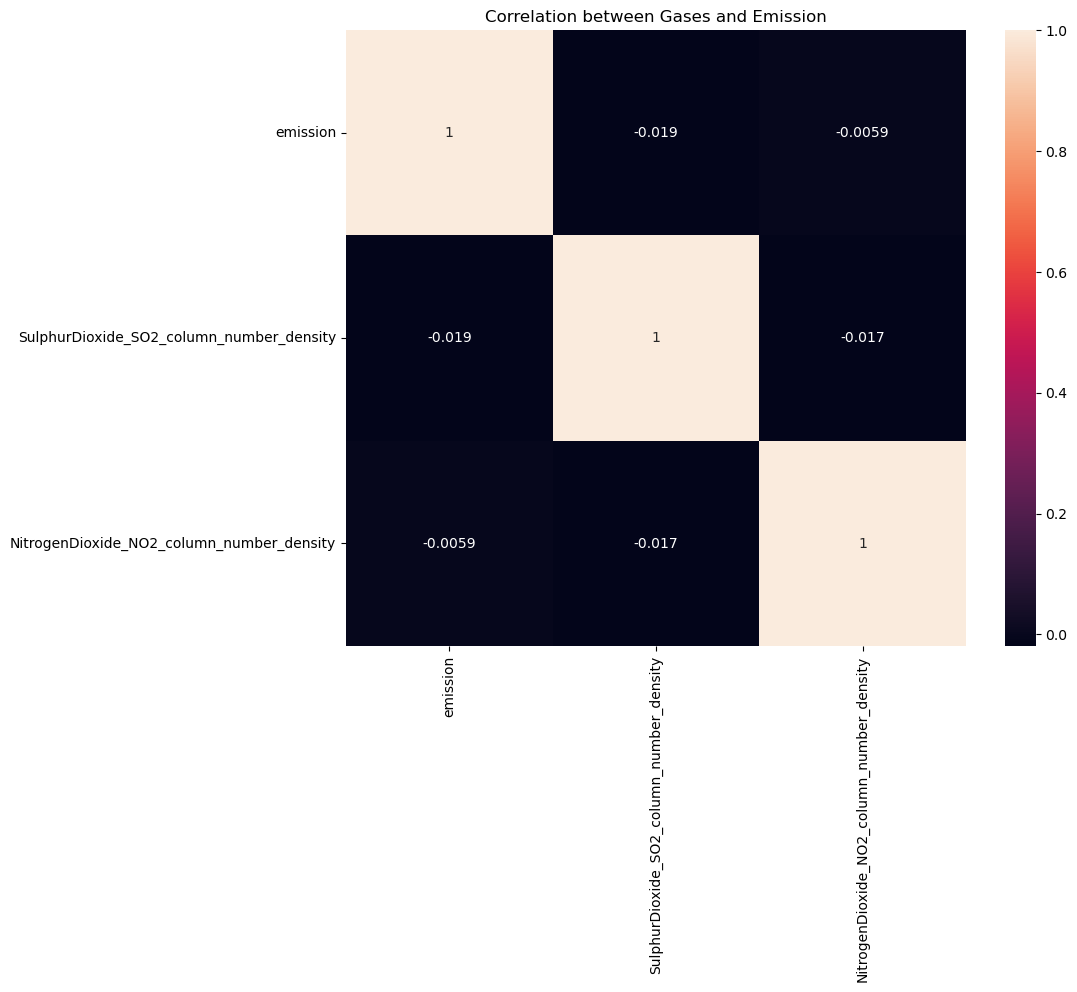

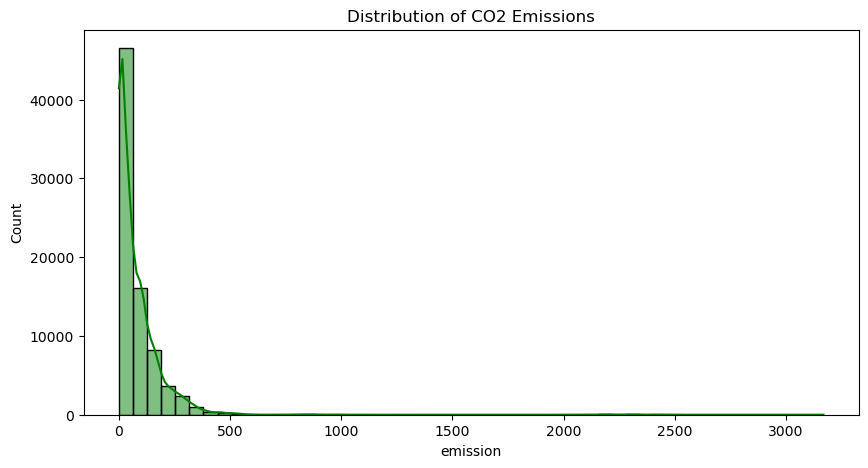

In [13]:
# Emission Trends for a specific location 
sample_loc = train[(train['latitude'] == -0.51) & (train['longitude'] == 29.29)]
plt.figure(figsize=(12, 6))
sns.lineplot(data=sample_loc, x='week_no', y='emission', hue='year')
plt.title('CO2 Emissions Trend for Location (Lat: -0.51, Lon: 29.29)')
plt.show()

# Heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(train[['emission', 'SulphurDioxide_SO2_column_number_density', 'NitrogenDioxide_NO2_column_number_density']].corr(), annot=True)
plt.title('Correlation between Gases and Emission')
plt.show()

# Target Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(train['emission'], bins=50, kde=True, color='green')
plt.title('Distribution of CO2 Emissions')
plt.show()

# Feature Importance Plot 
importances = model.feature_importances_ if hasattr(model, 'feature_importances_') else None

if importances is not None:
    feature_imp = pd.Series(importances, index=features).sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_imp, y=feature_imp.index)
    plt.title('Top 10 Features affecting CO2 Emissions')
    plt.xlabel('Importance Score')
    plt.show()

**Comparison of Models:**

Model 1 (HistGradientBoosting): Very Fast (saves time), with good accuracy (R2 score: 0.93 to 0.96 %).

Model 2 (Random Forest): Best Accuracy (R2 Score: 0.96), but takes more time to train.

In my openion HistGradientBoostingRegressor is best for this problem because it handles null values on it's own and learns very fast (10X) faster than RandomForestRegressor. It's accuracy can be increased by assigning a larger value to 'max_iter' parameter. 